# H-001 · Does OBV-Confirmed Momentum Beat Raw Momentum?

Factor test for **H-001** (equities): whether momentum filtered by On-Balance Volume agreement predicts better than price momentum alone.

- **Idea** — Keep (or weight) price momentum only when OBV trend agrees with price direction; unconfirmed moves are flipped, zeroed, or soft-weighted.
- **Claim** — OBV-confirmed momentum has stronger next-day / next-week predictive power than raw momentum on the same universe.
- **Why it might work** — Volume-backed moves suggest informed flow; unconfirmed price moves are more likely to fade.
- **Data** — Daily OHLCV long panel; compare marginal lift over raw momentum on the same rebalance schedule.

**`normalize` (default `True`):** when `normalize=True`, `add_obv_confirmed_momentum` stores a **cross-sectional (CS)** feature — the percentile rank of the combined signal *within each date*. That is GBM-ready and comparable across names. Set `normalize=False` to keep the raw combined signal in its original scale.

**`mode` options** (column `obv_mom_{mode}` or `obv_mom_{mode}_{L}_{S}_{W}` when multi-window):

| Mode | Behavior |
|------|----------|
| `signed` (default) | Keep momentum when price and OBV trend signs agree; **flip the sign** (same magnitude) when they disagree. |
| `strict_zero` | Keep momentum when signs agree; set to **0** when they disagree. |
| `soft` | Continuous weight: `momentum × soft_weight`, where `soft_weight` is typically `2 × CS pct-rank(OBV trend) − 1` (not a hard agree/disagree gate). |

**Multi-window:** `lookback`, `skip`, and `obv_window` each accept an `int` or a list (cartesian product). One combo → `obv_mom_{mode}`; multiple → `obv_mom_{mode}_{L}_{S}_{W}`.

**Research IS:** load `s1_factor_panel_train.parquet` (train / research IS from the panel notebook; `RESEARCH_IS_FRACTION`, default `0.70`). Do not re-split it. Full census is `s1_factor_panel_full.parquet` (not for factor IC keep/kill). For **S1 equities** factor screens, Alphalens `periods=(1, 5, 21)` on the daily panel is the intended default (other sleeves may use different periods).

Use `data.processing.feature_store.add_obv_confirmed_momentum` rather than reimplementing the factor inline.

## 0. Imports & Config

Resolve the repo root, configure factor params (`lookback`, `skip`, `obv_window` as int or list; `mode`, `normalize`), and import `s1_factor_panel_train.parquet`, `add_obv_confirmed_momentum`, and Alphalens. The train parquet is already research IS; do not calculate another cutoff here.

In [8]:
import os
import sys

import alphalens as al
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

from data.processing.cleaner import forward_fill_panel
from data.processing.feature_implementation.obv_momentum import (
    add_raw_momentum,
    cross_sectional_pct_rank,
)
from data.processing.feature_store import add_obv_confirmed_momentum

# Jupyter cwd is often this notebook's folder, not the repo root; walk up until we find 01_data/ingestion.
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

TRAIN_PANEL_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_factor_panel_train.parquet"
)

TEARSHEET_DIR = os.path.join(
    ROOT, "02_research", "notebooks", "factor_tests", "tearsheets"
)

# --- Window screen (edit these lists) ---
LOOKBACKS = [126, 252]      # L
SKIPS = [0, 21]             # S
OBV_WINDOWS = [10, 20, 63]  # W
# Cartesian product: every (L, S, W) with L > S is tested below via the store.

# --- Fixed for this notebook (not screened) ---
MODE = "soft"  # fixed
NORMALIZE = True      # fixed
PERIODS = (1, 5, 21)  # fixed — H-001 / S1 default; primary narrative = 5d
QUANTILES = 5
MAX_LOSS = 0.35


## 1. Data Loading

Load `s1_factor_panel_train.parquet`, which contains the daily OHLCV chronological research IS selected by `RESEARCH_IS_FRACTION` in the panel notebook. Confirm columns needed by the feature store: `date`, `ticker`, `close`, `volume`.

Do not apply another 70/30 split in this notebook.

In [9]:
panel = pd.read_parquet(TRAIN_PANEL_PATH)
required = {"date", "ticker", "close", "volume"}
missing = required - set(panel.columns)
if missing:
    raise ValueError(f"train panel missing columns: {sorted(missing)}")

panel = panel.copy()
panel["date"] = pd.to_datetime(panel["date"])
print(f"rows={len(panel):,}  tickers={panel['ticker'].nunique():,}  "
      f"dates={panel['date'].nunique():,}  "
      f"[{panel['date'].min().date()} → {panel['date'].max().date()}]")
panel.head()


rows=115,000  tickers=100  dates=1,150  [2020-01-02 → 2024-07-29]


,date,ticker,open,high,low,close,volume
0,2020-01-02,AAPL,71.344062,72.394093,71.091191,72.333885,135480400
1,2020-01-02,ABBV,67.852721,68.225955,67.418550,68.210724,5639200
2,2020-01-02,ABT,75.995215,76.789960,75.765627,76.781128,4969000
3,2020-01-02,ACN,189.265376,190.216817,187.425318,188.628082,2431100
4,2020-01-02,ADBE,330.000000,334.480011,329.170013,334.429993,1990100


## 2. Data Cleaning & Engineering

Clean the long panel as needed (missing bars, winsorize, etc.) via project cleaners. Stay in **long format**.

Point-in-time only: features at `t` use information available at or before `t`.

In [10]:
panel = forward_fill_panel(panel, columns=["close", "volume"], limit=5)
panel = panel.dropna(subset=["close", "volume"]).reset_index(drop=True)
print(f"after clean: rows={len(panel):,}  "
      f"null close={panel['close'].isna().sum()}  "
      f"null volume={panel['volume'].isna().sum()}")


after clean: rows=115,000  null close=0  null volume=0


## 3. Modeling / Signal Construction

Build both factors on the **same** cleaned panel so the comparison is fair.

### 3.1 Raw momentum (baseline)

Skip-month style: `P_{t-S} / P_{t-L} - 1` (e.g. L = 252, S = 21). Control factor for the paired test.

### 3.2 OBV-confirmed momentum (H-001)

Call `add_obv_confirmed_momentum` with the chosen `mode` and `normalize`.

- With `normalize=True`, output is a **CS-ranked** feature (`obv_mom_{mode}`).
- With `normalize=False`, output is the unranked combined signal.
- Optionally run more than one `mode` (`signed` / `strict_zero` / `soft`) side by side for sensitivity — note which is primary.

In [11]:
def add_cs_ranked_raw_momentum(
    panel: pd.DataFrame,
    *,
    lookback: int,
    skip: int,
) -> pd.DataFrame:
    """Add CS pct-ranked raw momentum as ``raw_momentum_{L}_{S}`` (normalize=True parity)."""
    raw_col = f"_raw_momentum_tmp_{lookback}_{skip}"
    out_col = f"raw_momentum_{lookback}_{skip}"
    out = add_raw_momentum(panel, lookback=lookback, skip=skip, col=raw_col)
    out[out_col] = cross_sectional_pct_rank(out, raw_col)
    return out.drop(columns=[raw_col])


In [12]:
panel = add_obv_confirmed_momentum(
    panel,
    lookback=LOOKBACKS,
    skip=SKIPS,
    obv_window=OBV_WINDOWS,
    mode=MODE,
    normalize=NORMALIZE,
)

OBV_COLS = [c for c in panel.columns if c.startswith(f"obv_mom_{MODE}")]
unique_ls = sorted({(L, S) for L in LOOKBACKS for S in SKIPS if L > S})
RAW_COLS = []
for L, S in unique_ls:
    panel = add_cs_ranked_raw_momentum(panel, lookback=L, skip=S)
    RAW_COLS.append(f"raw_momentum_{L}_{S}")

FACTOR_COLS = OBV_COLS + RAW_COLS
print(f"OBV factors ({len(OBV_COLS)}): {OBV_COLS}")
print(f"Raw baselines ({len(RAW_COLS)}): {RAW_COLS}")


OBV factors (12): ['obv_mom_soft_126_0_10', 'obv_mom_soft_126_0_20', 'obv_mom_soft_126_0_63', 'obv_mom_soft_126_21_10', 'obv_mom_soft_126_21_20', 'obv_mom_soft_126_21_63', 'obv_mom_soft_252_0_10', 'obv_mom_soft_252_0_20', 'obv_mom_soft_252_0_63', 'obv_mom_soft_252_21_10', 'obv_mom_soft_252_21_20', 'obv_mom_soft_252_21_63']
Raw baselines (4): ['raw_momentum_126_0', 'raw_momentum_126_21', 'raw_momentum_252_0', 'raw_momentum_252_21']


## 4. Evaluation

Paired comparison of **raw momentum** vs **OBV-confirmed momentum** on identical research-IS universe and dates from `s1_factor_panel_train.parquet`. For **S1 equities**, use Alphalens `periods=(1, 5, 21)` on the daily panel (primary narrative 5d); other strategies may choose different periods. Screen window lists on this IS only.

### 4.1 Window screen summary

Factor column names encode the windows used. Lists `LOOKBACKS` × `SKIPS` × `OBV_WINDOWS` are **cartesian-producted** in `add_obv_confirmed_momentum`.

| Token | Meaning | Formula / role |
|-------|---------|----------------|
| `mode` | Confirmation rule | Fixed to `soft` in this notebook |
| **L** (`lookback`) | Start-price lag | Momentum uses `P_{t-S} / P_{t-L} - 1` |
| **S** (`skip`) | End-price lag | Skips the most recent S days so short-term reversal does not contaminate momentum |
| **W** (`obv_window`) | OBV trend length | `OBV_t - OBV_{t-W}` |

**Column patterns**

- OBV (multi-combo): `obv_mom_{mode}_{L}_{S}_{W}` — e.g. `obv_mom_signed_252_21_20`
- Raw baseline: `raw_momentum_{L}_{S}` — same L/S as the momentum legs; no W

Primary ranking metric below: **mean IC at 5d** (`ic_5d`).


In [13]:
def to_alphalens_prices(panel: pd.DataFrame) -> pd.DataFrame:
    """Wide close matrix for Alphalens only (dates × tickers)."""
    prices = panel.pivot(index="date", columns="ticker", values="close")
    prices.index = pd.to_datetime(prices.index)
    return prices.sort_index()


def to_alphalens_factor(panel: pd.DataFrame, col: str) -> pd.Series:
    """MultiIndex (date, ticker) factor series for Alphalens."""
    factor = panel.set_index(["date", "ticker"])[col].dropna()
    factor.index = factor.index.set_levels(
        pd.to_datetime(factor.index.levels[0]), level=0
    )
    return factor.sort_index()


def parse_factor_name(col: str) -> dict:
    """Decode ``obv_mom_{mode}_{L}_{S}_{W}`` or ``raw_momentum_{L}_{S}``."""
    if col.startswith("raw_momentum_"):
        parts = col.split("_")
        # raw_momentum_{L}_{S}
        return {"kind": "raw", "L": int(parts[-2]), "S": int(parts[-1]), "W": pd.NA}
    if col.startswith("obv_mom_"):
        parts = col.split("_")
        # obv_mom_{mode}_{L}_{S}_{W}
        return {
            "kind": "obv",
            "L": int(parts[-3]),
            "S": int(parts[-2]),
            "W": int(parts[-1]),
        }
    raise ValueError(f"unrecognized factor column: {col!r}")


def _period_label(period_index: pd.Index, period: int, position: int):
    """Match Alphalens period label ('1D', '5D', …) or fall back by position."""
    for c in (f"{period}D", f"{period}d", period, str(period)):
        if c in period_index:
            return c
    return period_index[position]


def factor_screen_metrics(
    factor: pd.Series,
    prices: pd.DataFrame,
    *,
    periods: tuple[int, ...] = PERIODS,
    quantiles: int = QUANTILES,
    max_loss: float = MAX_LOSS,
) -> dict:
    """Mean IC and Q5−Q1 mean return spread for each forward period."""
    factor_data = al.utils.get_clean_factor_and_forward_returns(
        factor=factor,
        prices=prices,
        quantiles=quantiles,
        periods=periods,
        max_loss=max_loss,
    )
    mean_ic = al.performance.mean_information_coefficient(factor_data)
    mean_ret, _ = al.performance.mean_return_by_quantile(factor_data, demeaned=True)

    row = {}
    for i, p in enumerate(periods):
        ic_key = _period_label(mean_ic.index, p, i)
        ret_key = _period_label(mean_ret.columns, p, i)
        row[f"ic_{p}d"] = float(mean_ic.loc[ic_key])
        q_hi, q_lo = mean_ret.index.max(), mean_ret.index.min()
        row[f"spread_{p}d"] = float(
            mean_ret.loc[q_hi, ret_key] - mean_ret.loc[q_lo, ret_key]
        )
    return row


In [14]:
prices = to_alphalens_prices(panel)

rows = []
for col in FACTOR_COLS:
    meta = parse_factor_name(col)
    metrics = factor_screen_metrics(to_alphalens_factor(panel, col), prices)
    rows.append({"factor": col, **meta, **metrics})

summary = (
    pd.DataFrame(rows)
    .sort_values("ic_5d", ascending=False)
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
summary


Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Dropped 2.1% en

,factor,kind,L,S,W,ic_1d,spread_1d,ic_5d,spread_5d,ic_21d,spread_21d
0,obv_mom_soft_126_21_63,obv,126,21,63,0.0093,0.0004,0.0203,0.0017,0.0439,0.0099
1,obv_mom_soft_126_0_63,obv,126,0,63,0.0075,0.0004,0.0183,0.0017,0.0405,0.0082
2,raw_momentum_126_0,raw,126,0,<NA>,0.0158,0.0002,0.0172,0.0011,0.0158,0.0023
3,raw_momentum_252_21,raw,252,21,<NA>,0.0154,0.0001,0.0166,0.0004,0.0158,0.0011
4,raw_momentum_252_0,raw,252,0,<NA>,0.0145,0.0001,0.0161,0.0002,0.0121,-0.0009
5,raw_momentum_126_21,raw,126,21,<NA>,0.0164,0.0002,0.0142,0.0010,0.0112,0.0023
6,obv_mom_soft_252_0_63,obv,252,0,63,0.0038,0.0001,0.0063,-0.0001,0.0166,0.0029
7,obv_mom_soft_126_21_20,obv,126,21,20,0.0036,0.0002,0.0059,0.0008,0.0074,0.0027
8,obv_mom_soft_126_0_20,obv,126,0,20,0.0002,0.0002,0.0052,0.0009,0.0055,0.0029
9,obv_mom_soft_252_21_63,obv,252,21,63,0.0038,0.0002,0.0050,0.0003,0.0131,0.0037


### 4.2 Full tear sheet (manual OBV combo)

Review the summary table in §4.1, then set `TEAR_LOOKBACK` (L), `TEAR_SKIP` (S), and `TEAR_OBV_WINDOW` (W) in the cell below. The tear sheet runs on `obv_mom_{MODE}_{L}_{S}_{W}` for those values — nothing is auto-selected.

The tear is displayed in-notebook **and** saved as a multi-page PDF under `02_research/notebooks/factor_tests/tearsheets/` named `H-001_obv_mom_{mode}_{L}_{S}_{W}.pdf` (hypothesis id + factor column, including window/mode args). Re-running overwrites the same path.


In [17]:
def obv_factor_col(lookback: int, skip: int, obv_window: int, *, mode: str = MODE) -> str:
    """Column name for a multi-window OBV factor: ``obv_mom_{mode}_{L}_{S}_{W}``."""
    return f"obv_mom_{mode}_{lookback}_{skip}_{obv_window}"


def run_full_tear(
    panel: pd.DataFrame,
    factor_col: str,
    prices: pd.DataFrame,
    *,
    periods: tuple[int, ...] = PERIODS,
    quantiles: int = QUANTILES,
    max_loss: float = MAX_LOSS,
    tearsheet_dir: str = TEARSHEET_DIR,
):
    """Build factor_data, run Alphalens full tear, save figs to multi-page PDF.

    Alphalens calls plt.show() after each plot, which clears figures under Agg.
    Temporarily replace plt.show so each figure is written into the PDF before close.
    """
    if factor_col not in panel.columns:
        raise ValueError(
            f"{factor_col!r} not in panel — pick L/S/W that were screened "
            f"(available: {OBV_COLS})"
        )
    plt.close("all")
    factor_data = al.utils.get_clean_factor_and_forward_returns(
        factor=to_alphalens_factor(panel, factor_col),
        prices=prices,
        quantiles=quantiles,
        periods=periods,
        max_loss=max_loss,
    )

    os.makedirs(tearsheet_dir, exist_ok=True)
    out_path = os.path.join(tearsheet_dir, f"H-001_{factor_col}.pdf")
    pdf = PdfPages(out_path)
    n_pages = 0
    _original_show = plt.show

    def _show_and_savefig(*args, **kwargs):
        nonlocal n_pages
        for num in list(plt.get_fignums()):
            fig = plt.figure(num)
            if fig.axes:
                pdf.savefig(fig, bbox_inches="tight")
                n_pages += 1
        plt.close("all")

    plt.show = _show_and_savefig
    try:
        al.tears.create_full_tear_sheet(factor_data, long_short=True)
        _show_and_savefig()
    finally:
        plt.show = _original_show
        pdf.close()
        plt.close("all")

    print(f"Wrote {out_path} ({n_pages} pages)")
    return factor_data


Tear sheet factor: obv_mom_soft_126_21_63
Dropped 2.1% entries from factor data: 2.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.0100,0.2000,0.1050,0.0577,20060,20.0000
2,0.2100,0.4000,0.3050,0.0577,20060,20.0000
3,0.4100,0.6000,0.5050,0.0577,20060,20.0000
4,0.6100,0.8000,0.7050,0.0577,20060,20.0000
5,0.8100,1.0000,0.9050,0.0577,20060,20.0000


Returns Analysis


,1D,5D,21D
Ann. alpha,0.0470,0.0400,0.0460
beta,0.0240,0.0270,0.0120
Mean Period Wise Return Top Quantile (bps),2.9780,2.4180,2.6800
Mean Period Wise Return Bottom Quantile (bps),-0.6300,-1.0720,-2.0350
Mean Period Wise Spread (bps),3.6090,3.4430,4.6740


<Figure size 640x480 with 0 Axes>

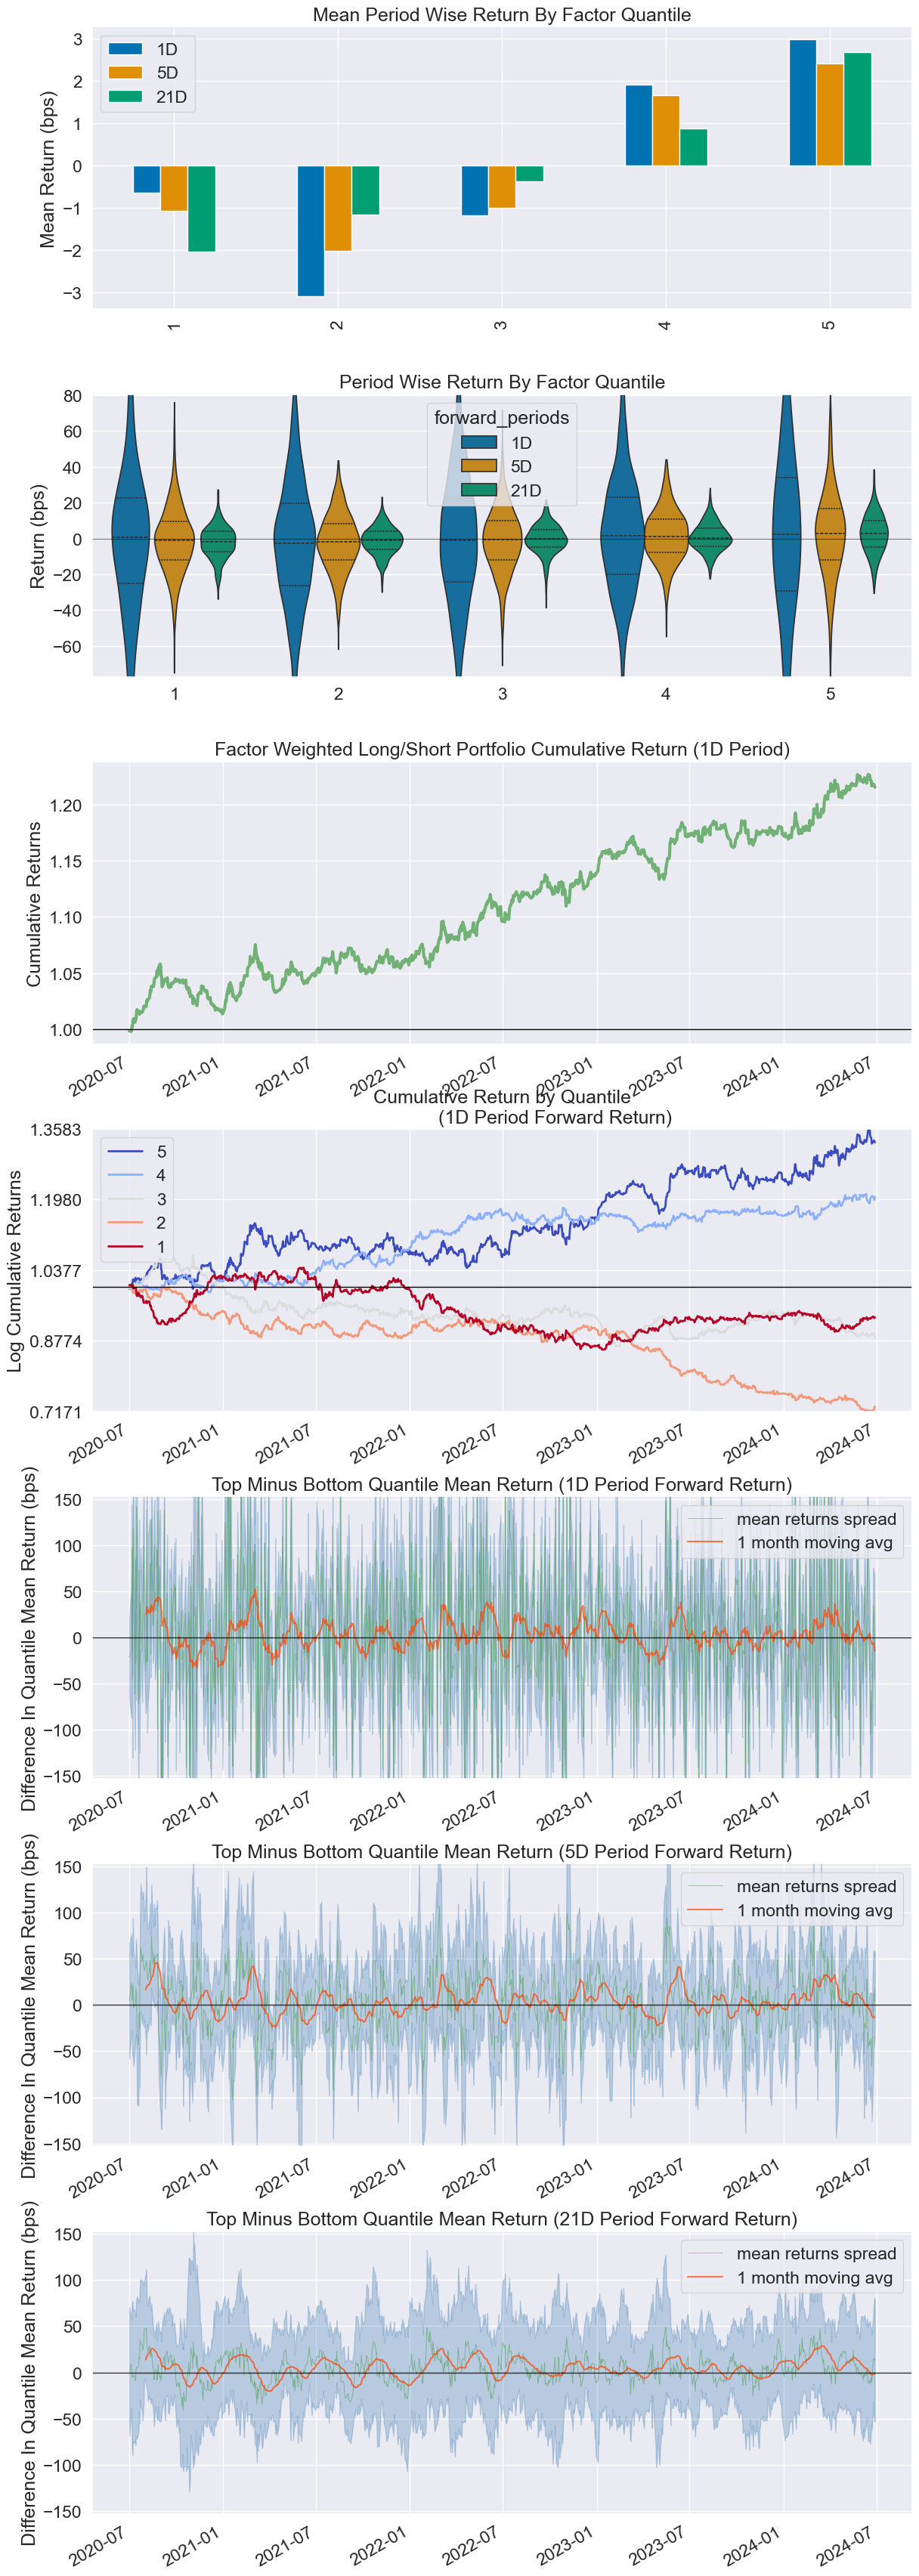

Information Analysis


,1D,5D,21D
IC Mean,0.0090,0.0200,0.0440
IC Std.,0.1460,0.1340,0.1350
Risk-Adjusted IC,0.0640,0.1520,0.3240
t-stat(IC),2.0170,4.8030,10.2750
p-value(IC),0.0440,0.0000,0.0000
IC Skew,-0.0880,-0.3120,-0.2610
IC Kurtosis,-0.2480,-0.0790,-0.0290


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


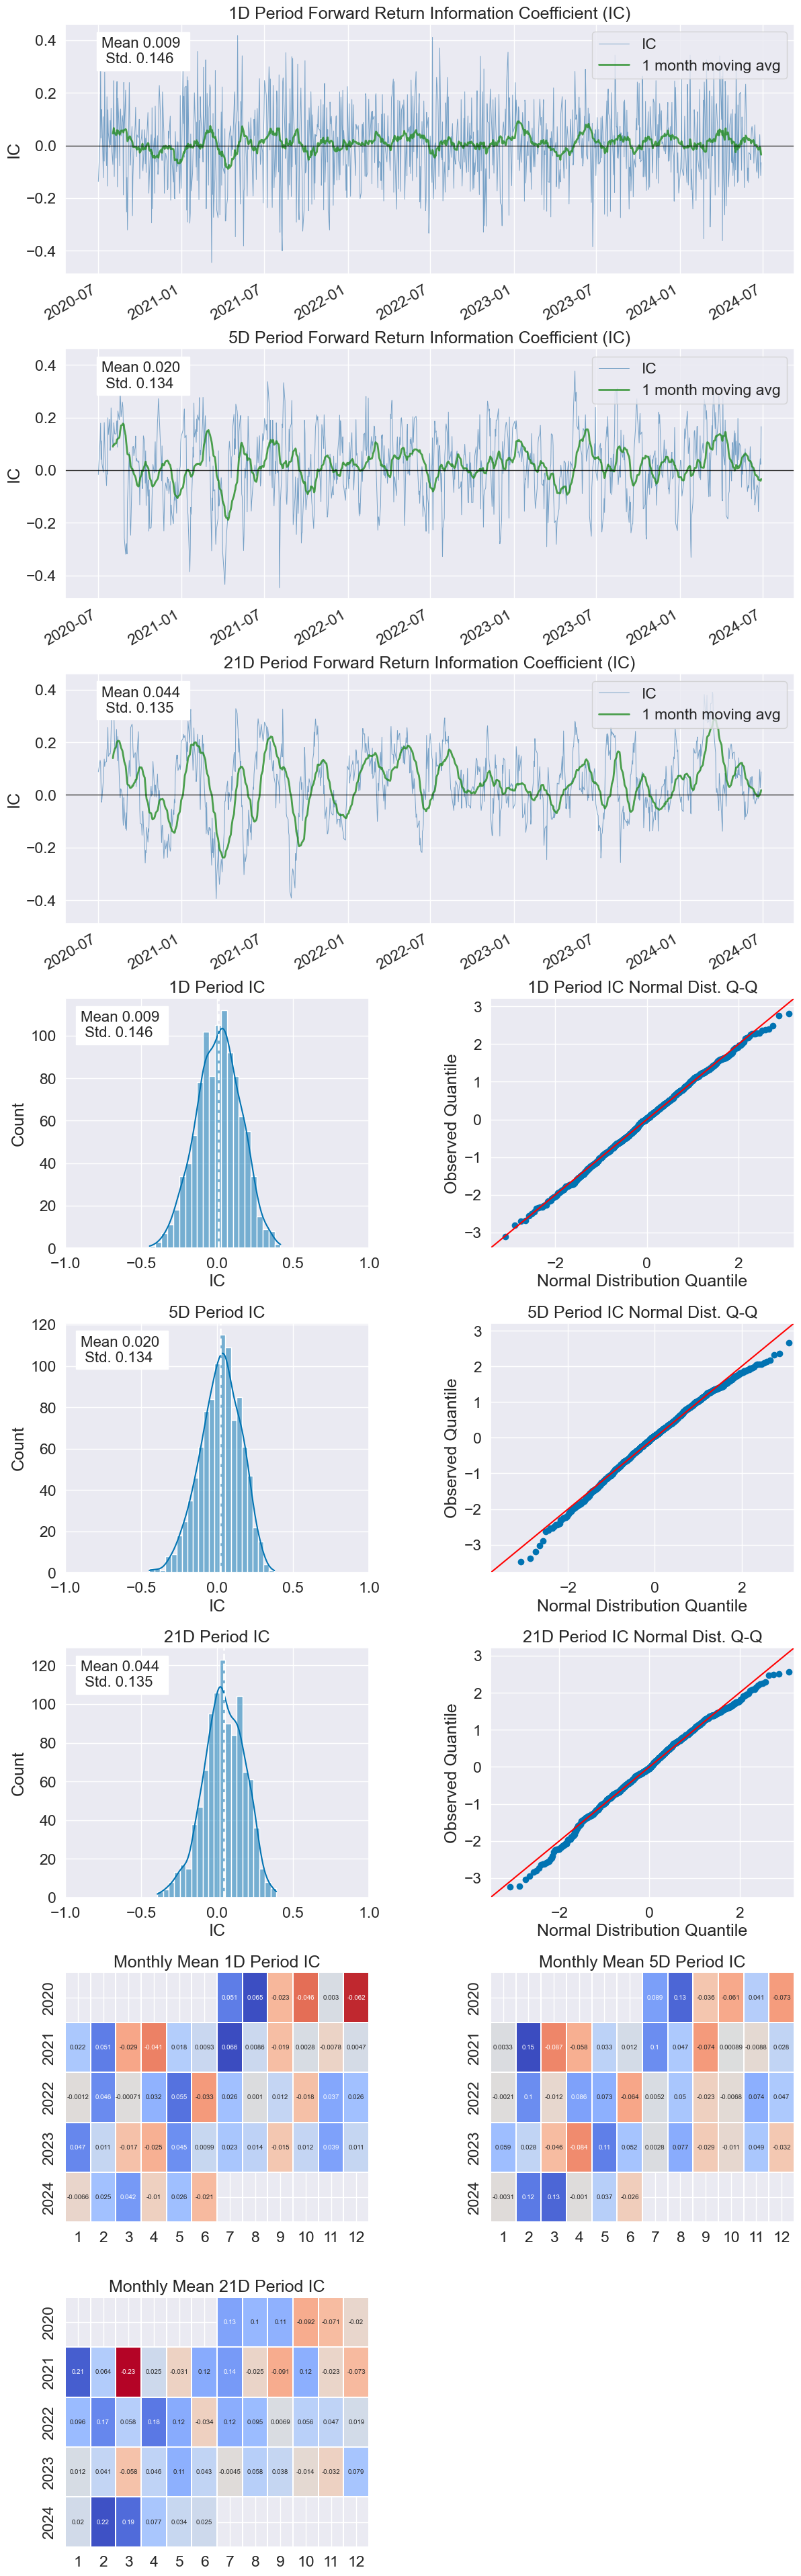

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,21D
Quantile 1 Mean Turnover,0.1630,0.3330,0.6160
Quantile 2 Mean Turnover,0.3120,0.5110,0.6700
Quantile 3 Mean Turnover,0.3280,0.5350,0.7030
Quantile 4 Mean Turnover,0.2590,0.4790,0.6900
Quantile 5 Mean Turnover,0.1100,0.2290,0.4140


,1D,5D,21D
Mean Factor Rank Autocorrelation,0.9350,0.7840,0.4370


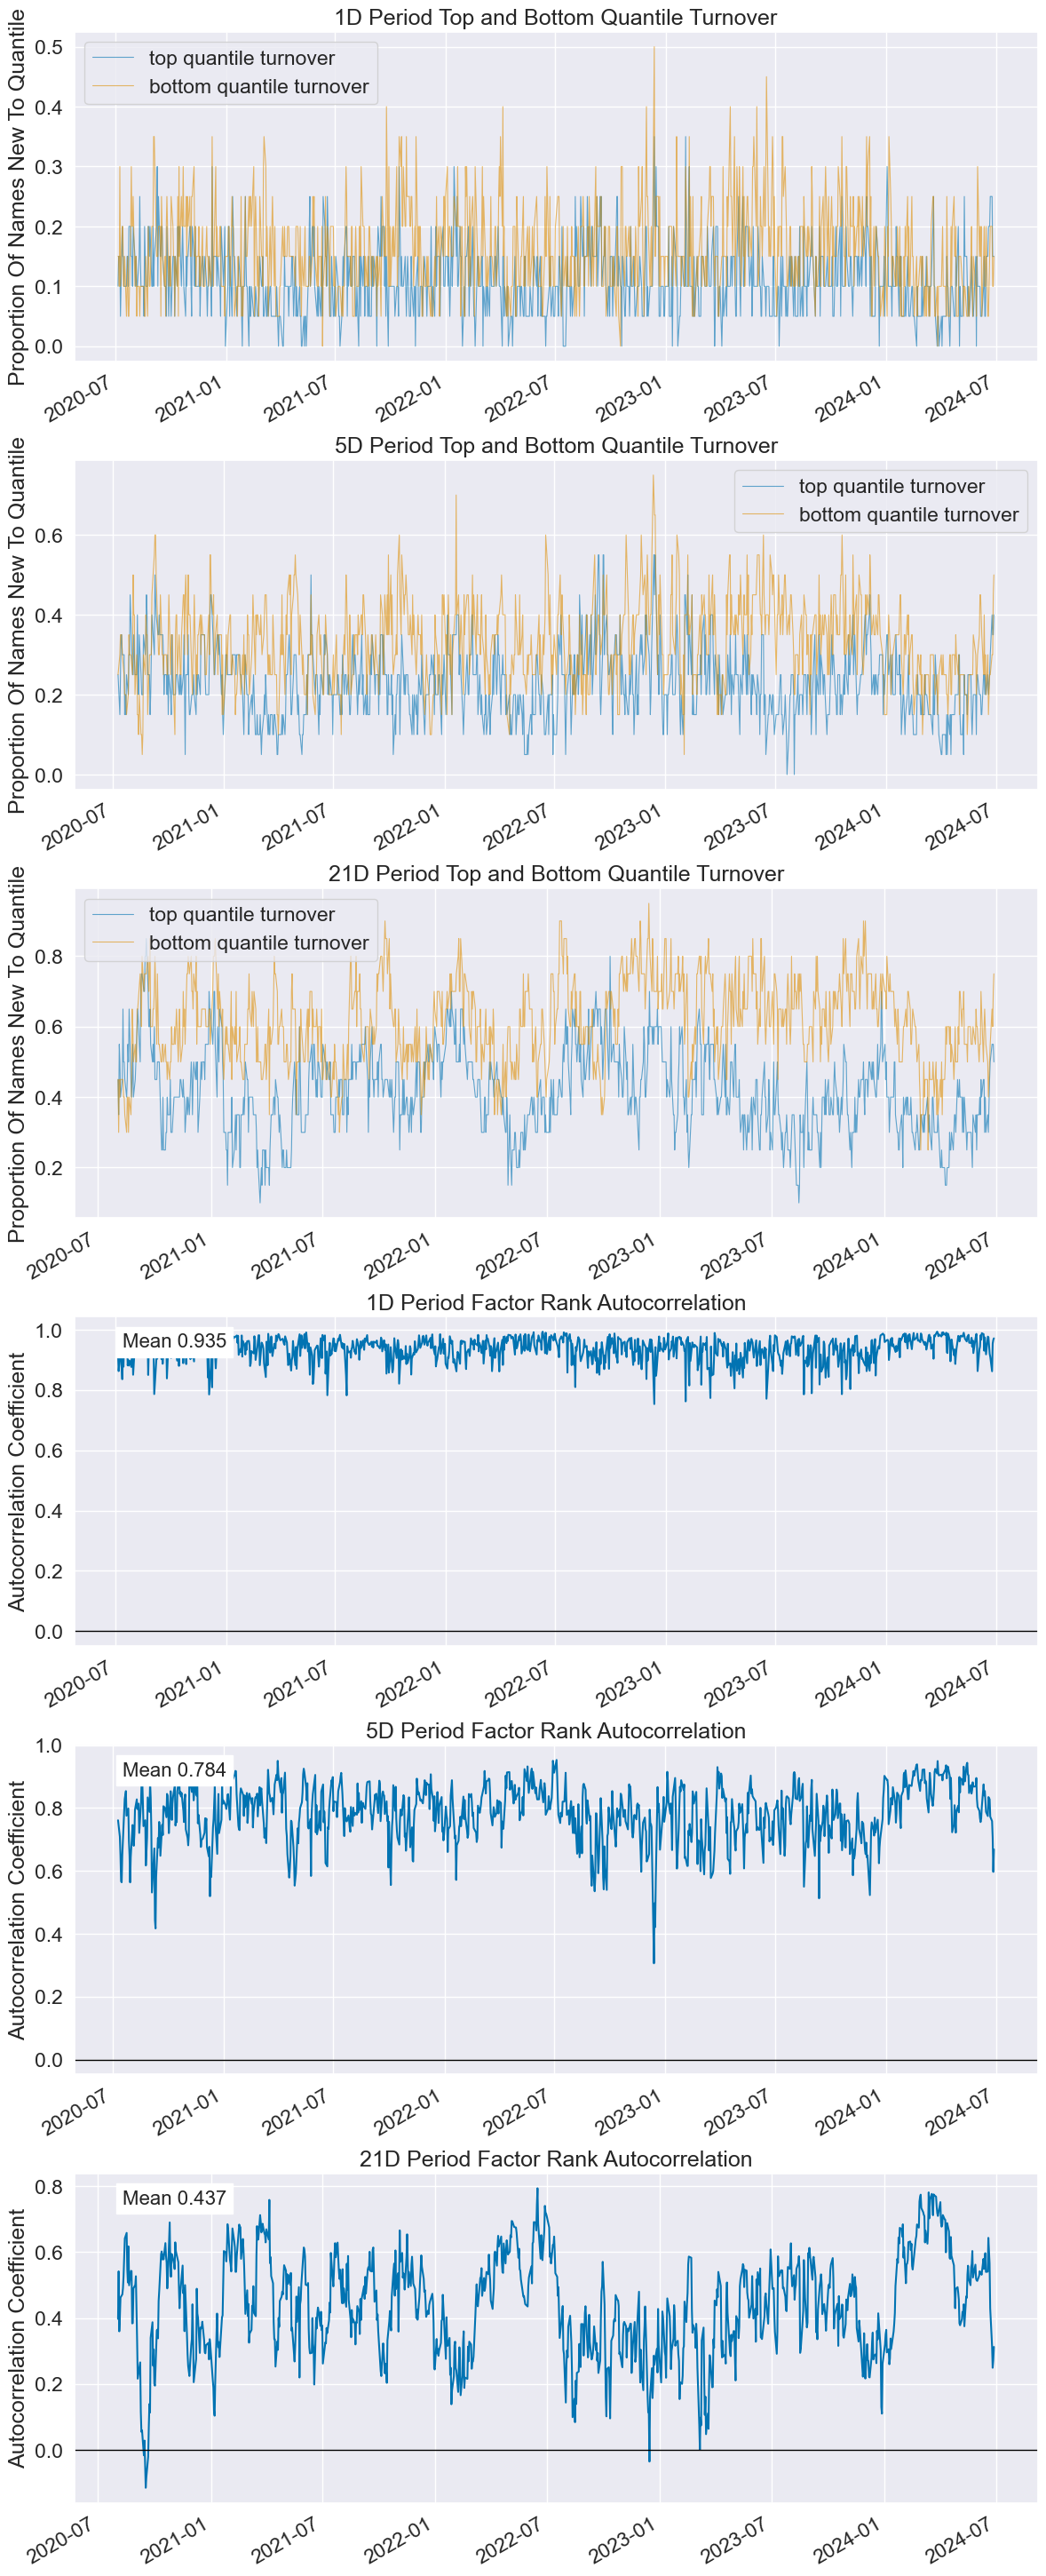

In [18]:
# --- Edit after reviewing the §4.1 summary table ---
TEAR_LOOKBACK = 126       # L
TEAR_SKIP = 21            # S
TEAR_OBV_WINDOW = 63      # W

tear_col = obv_factor_col(TEAR_LOOKBACK, TEAR_SKIP, TEAR_OBV_WINDOW)
print(f"Tear sheet factor: {tear_col}")
tear_factor_data = run_full_tear(panel, tear_col, prices)


## Conclusion

A soft weighted OBV with:

TEAR_LOOKBACK = 126
TEAR_SKIP = 21
TEAR_OBV_WINDOW = 63

could be used as a factor achieving a mean IC of around 0.02.
Learning weights would lead to overfitting so just keep it as a soft weight - but also give the model raw_momentum and OBV trend and use the feature rankings to find which is most useful.